In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load cleaned data directly
df = pd.read_csv('../data/cleaned_trips.csv')

X = df.drop('trip_duration_mins', axis=1)
y = df['trip_duration_mins']

print("Ready. X shape:", X.shape)
print("y shape:", y.shape)

Ready. X shape: (199700, 11)
y shape: (199700,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.42,random_state=42)

print("Train Size",X_train.shape)
print("test size", X_test.shape)

Train Size (115826, 11)
test size (83874, 11)


In [3]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np 

lr=LinearRegression() #model

lr.fit(X_train,y_train) #train

y_pred_lr=lr.predict(X_test) #predict

#evaluate
mae=mean_absolute_error(y_test,y_pred_lr)
rmse = np.sqrt(((y_test - y_pred_lr) ** 2).mean())
r2 = r2_score(y_test, y_pred_lr)

print ("Linear Regression Results:")
print (f" MAE : {mae:.2f} mins")
print (f" RMSE : {rmse:.2f} mins")
print (f" R2 score : {r2:.4f} mins ")

Linear Regression Results:
 MAE : 5.35 mins
 RMSE : 7.65 mins
 R2 score : 0.6472 mins 


In [4]:
#Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt=dt.predict(X_test)

mae=mean_absolute_error(y_test,y_pred_dt)
rmse= np.sqrt(((y_test- y_pred_dt) **2).mean())
r2= r2_score (y_test,y_pred_dt)

print(" Decision Tree Result")
print (f" MAE : {mae:.2f} mins")
print (f" RMSE : {rmse:.2f} mins")
print (f" R2 score : {r2:.4f} mins")

 Decision Tree Result
 MAE : 5.72 mins
 RMSE : 8.65 mins
 R2 score : 0.5493 mins


In [5]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100 , random_state=42 , n_jobs= -1)
rf.fit (X_train, y_train)

y_pred_rf=rf.predict(X_test)

mae=mean_absolute_error(y_test,y_pred_rf)
rmse= np.sqrt (((y_test - y_pred_rf)**2).mean())
r2=r2_score (y_test, y_pred_rf)

print ("Random Forest Results:")
print (f" MAE : {mae:.2f} mins")
print (f" RMSE : {rmse:.2f} mins")
print (f" R2 : {r2:.4f}")

Random Forest Results:
 MAE : 4.06 mins
 RMSE : 6.09 mins
 R2 : 0.7761


In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(((y_test - y_pred_xgb) ** 2).mean())
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"  MAE  : {mae:.2f} mins")
print(f"  RMSE : {rmse:.2f} mins")
print(f"  R²   : {r2:.4f}")

XGBoost Results:
  MAE  : 3.70 mins
  RMSE : 5.65 mins
  R²   : 0.8075


In [7]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lgbm)
rmse = np.sqrt(((y_test - y_pred_lgbm) ** 2).mean())
r2 = r2_score(y_test, y_pred_lgbm)

print("LightGBM Results:")
print(f"  MAE  : {mae:.2f} mins")
print(f"  RMSE : {rmse:.2f} mins")
print(f"  R²   : {r2:.4f}")

LightGBM Results:
  MAE  : 3.83 mins
  RMSE : 5.80 mins
  R²   : 0.7972


In [8]:
# Final comparison table
import pandas as pd

results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'MAE': [5.35, 5.72, 4.06, 3.70, 3.83],
    'RMSE': [7.65, 8.65, 6.09, 5.65, 5.80],
    'R²': [0.6472, 0.5493, 0.7761, 0.8075, 0.7972]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model  MAE  RMSE     R²
Linear Regression 5.35  7.65 0.6472
    Decision Tree 5.72  8.65 0.5493
    Random Forest 4.06  6.09 0.7761
          XGBoost 3.70  5.65 0.8075
         LightGBM 3.83  5.80 0.7972


In [9]:
results_df

,Model,MAE,RMSE,R²
0,Linear Regression,5.35,7.65,0.6472
1,Decision Tree,5.72,8.65,0.5493
2,Random Forest,4.06,6.09,0.7761
3,XGBoost,3.70,5.65,0.8075
4,LightGBM,3.83,5.80,0.7972


In [12]:
comparison = pd.DataFrame({
    'Actual (mins)': y_test.iloc[:20].round(2).values,
    'Predicted (mins)': xgb.predict(X_test.iloc[:20]).round(2),
    'Difference (mins)': (y_test.iloc[:20].values - xgb.predict(X_test.iloc[:20])).round(2)
})

comparison

,Actual (mins),Predicted (mins),Difference (mins)
0,5.50,5.890000,-0.39
1,13.52,13.650000,-0.13
2,54.70,52.480000,2.22
3,16.42,20.959999,-4.54
4,25.12,27.840000,-2.72
5,18.28,22.120001,-3.83
6,8.50,9.800000,-1.30
7,7.72,12.840000,-5.12
8,16.80,16.940001,-0.14
9,15.12,20.180000,-5.06


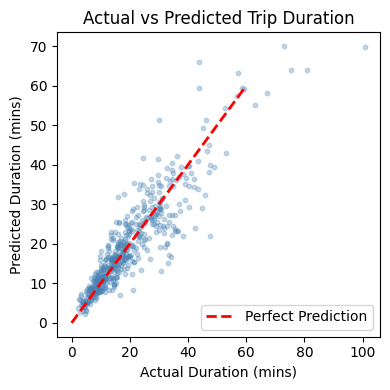

In [14]:
import matplotlib.pyplot as plt
import numpy as np

sample_idx = np.random.choice(len(y_test), 500, replace=False)
actual = y_test.iloc[sample_idx].values
predicted = xgb.predict(X_test.iloc[sample_idx])

plt.figure(figsize=(4 ,4))
plt.scatter(actual, predicted, alpha=0.3, color='steelblue', s=10)
plt.plot([0, 60], [0, 60], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Duration (mins)')
plt.ylabel('Predicted Duration (mins)')
plt.title('Actual vs Predicted Trip Duration')
plt.legend()
plt.tight_layout()
plt.show()